# CA Affordable Housing Tax Credit Intelligence Platform
## Notebook 04 — Modeling

**Input:** Fitted pipeline + train/test splits from `03_feature_engineering.ipynb`

**Models:**
1. Ridge Regression (interpretable baseline)
2. Random Forest
3. XGBoost — **deployed point estimator**
4. LightGBM Quantile (p10/p50/p90, tuned per-α with pinball-loss CV) + per-row sort to fix crossings
5. Split conformal on XGBoost (90% target coverage) — **deployed prediction interval**
6. Stacking v2 (RF + XGBoost + tuned LightGBM-p50 → Ridge meta) — offline benchmark
7. KNN (market comparables) + KMeans (project archetypes)

**All regression models** train on `log1p(annual_federal_award)` and back-transform via `expm1()`.

**Output:** `models/*.pkl` — all saved models for Streamlit app

In [1]:
import warnings
import os
import gc
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_pinball_loss
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import shap

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.4f}'.format)

# Memory-safe: n_jobs=1 avoids subprocess data duplication that causes OOM on laptops.
# n_jobs=-1 spawns one process per CPU core, each copying the full dataset into memory.
N_JOBS = 1

MODEL_DIR = '../models'
print('Setup complete')

Setup complete


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data from Notebook 03

In [2]:
# Load pre-transformed arrays
X_train = np.load(os.path.join(MODEL_DIR, 'X_train.npy'))
X_test = np.load(os.path.join(MODEL_DIR, 'X_test.npy'))
y_train_raw = np.load(os.path.join(MODEL_DIR, 'y_train.npy'))
y_test_raw = np.load(os.path.join(MODEL_DIR, 'y_test.npy'))

# Load raw DataFrames for metadata / comparables
df_train = pd.read_parquet(os.path.join(MODEL_DIR, 'train_data.parquet'))
df_test = pd.read_parquet(os.path.join(MODEL_DIR, 'test_data.parquet'))

# Load feature config
feature_config = joblib.load(os.path.join(MODEL_DIR, 'feature_config.pkl'))
feature_names = feature_config['feature_names_out']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {len(y_train_raw):,}, y_test: {len(y_test_raw):,}')

X_train: (3536, 28), X_test: (851, 28)
y_train: 3,536, y_test: 851


## 2. Log-Transform Target

All regression models train on `log1p(annual_federal_award)` to reduce right skew (raw train skewness 4.31 → -0.28; raw test 1.38 → -0.39).

In [3]:
y_train = np.log1p(y_train_raw)
y_test = np.log1p(y_test_raw)

from scipy.stats import skew
print(f'Raw train skewness:  {skew(y_train_raw):.2f}')
print(f'Log train skewness:  {skew(y_train):.2f}')
print(f'Raw test skewness:   {skew(y_test_raw):.2f}')
print(f'Log test skewness:   {skew(y_test):.2f}')

Raw train skewness:  4.31
Log train skewness:  -0.28
Raw test skewness:   1.38
Log test skewness:   -0.39


## 3. Helpers

In [4]:
def compute_metrics(name, y_true_raw, y_pred_raw):
    """Compute metrics on the original dollar scale."""
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    r2 = r2_score(y_true_raw, y_pred_raw)
    # MAPE — avoid division by zero
    mask = y_true_raw > 0
    mape = np.mean(np.abs((y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask])) * 100
    # % within 10% of actual
    pct_within_10 = np.mean(np.abs((y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask]) < 0.10) * 100
    
    return {
        'Model': name,
        'RMSE ($)': rmse,
        'MAE ($)': mae,
        'R2': r2,
        'MAPE (%)': mape,
        'Within 10%': pct_within_10,
    }


def fit_predict_log(name, model, X_tr, y_tr_log, X_te, y_te_raw):
    """Fit on log target, predict, back-transform, compute metrics."""
    model.fit(X_tr, y_tr_log)
    y_pred_log = model.predict(X_te)
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw = np.maximum(y_pred_raw, 0)  # floor at 0
    return compute_metrics(name, y_te_raw, y_pred_raw), y_pred_raw


results = []  # collect all model metrics

## 4. Cross-Validation Setup

Walk-forward `TimeSeriesSplit(n_splits=4)` within the 2000-2021 training window. The 2022-2025 holdout is never touched during tuning.

In [5]:
tscv = TimeSeriesSplit(n_splits=4)

# Verify folds
pis_years_train = df_train['pis_year'].values
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    tr_years = pis_years_train[tr_idx]
    val_years = pis_years_train[val_idx]
    print(f'Fold {i+1}: train {tr_years.min()}-{tr_years.max()} ({len(tr_idx):,}) -> '
          f'val {val_years.min()}-{val_years.max()} ({len(val_idx):,})')

Fold 1: train 2000-2005 (708) -> val 2005-2009 (707)
Fold 2: train 2000-2009 (1,415) -> val 2009-2014 (707)
Fold 3: train 2000-2014 (2,122) -> val 2014-2018 (707)
Fold 4: train 2000-2018 (2,829) -> val 2018-2021 (707)


## 5. Model 1 — Ridge Regression (Baseline)

In [6]:
# Cross-validate alpha
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=tscv, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
print(f'Best alpha: {ridge_cv.alpha_}')

# Final Ridge with best alpha
ridge = Ridge(alpha=ridge_cv.alpha_)
ridge_metrics, ridge_preds = fit_predict_log('Ridge', ridge, X_train, y_train, X_test, y_test_raw)
results.append(ridge_metrics)

print(f'Ridge R2: {ridge_metrics["R2"]:.4f}')
print(f'Ridge MAPE: {ridge_metrics["MAPE (%)"]:.1f}%')

Best alpha: 10.0
Ridge R2: -0.2949
Ridge MAPE: 43.2%


## 6. Model 2 — Random Forest

In [7]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=N_JOBS,
)
rf_search.fit(X_train, y_train)
print(f'Best RF params: {rf_search.best_params_}')

rf = rf_search.best_estimator_
rf_metrics, rf_preds = fit_predict_log('Random Forest', rf, X_train, y_train, X_test, y_test_raw)
results.append(rf_metrics)

print(f'RF R2: {rf_metrics["R2"]:.4f}')
print(f'RF MAPE: {rf_metrics["MAPE (%)"]:.1f}%')
gc.collect()

Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 15}


RF R2: 0.3935
RF MAPE: 29.5%


150

## 7. Model 3 — XGBoost

In [8]:
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 5.0, 10.0],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, tree_method='hist'),
    xgb_param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=N_JOBS,
)
xgb_search.fit(X_train, y_train)
print(f'Best XGBoost params: {xgb_search.best_params_}')

xgb = xgb_search.best_estimator_
xgb_metrics, xgb_preds = fit_predict_log('XGBoost', xgb, X_train, y_train, X_test, y_test_raw)
results.append(xgb_metrics)

print(f'XGBoost R2: {xgb_metrics["R2"]:.4f}')
print(f'XGBoost MAPE: {xgb_metrics["MAPE (%)"]:.1f}%')
gc.collect()

Best XGBoost params: {'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
XGBoost R2: 0.6167
XGBoost MAPE: 25.9%


822

## 8. Uncertainty Quantification (LightGBM Quantile + Split Conformal)

Two approaches, each producing a p10 / p90 prediction interval around the point estimate. We report both so the reader can compare interval **validity** (coverage) against **efficiency** (width).

**Why this section comes before the Stacking ensemble:** the stack in Section 9 uses the *tuned* LightGBM-p50 as one of its base learners, so we must tune it here first. Earlier versions of this notebook hardcoded the p50 hyperparameters inside the stack and tuned them separately in a later cell — that gave the stack an untuned base learner. Running the tune first and feeding the fitted estimator into the stack is the principled order.

### 8a. LightGBM Quantile Regression (tuned per-quantile)

Three LightGBM models with `objective='quantile'` (α = 0.1, 0.5, 0.9). **Each is tuned independently** via `RandomizedSearchCV` with a **pinball-loss scorer** — the proper scoring rule for quantile regression. Using fixed hyperparameters across quantiles (as in v1) is not a fair comparison: each α has a different loss surface.

**Pinball loss** at quantile α:
- Under-prediction penalty: α × |error|
- Over-prediction penalty: (1 − α) × |error|

At α = 0.9, under-predictions are penalized 9× more than over-predictions, pushing the model to be an upper bound. At α = 0.1, the reverse. At α = 0.5, it reduces to MAE and the model targets the conditional median.

**Quantile crossing fix:** independent models can produce p10 > p50 in rare rows. We enforce p10 ≤ p50 ≤ p90 with per-row `np.sort`.

### 8b. Split Conformal Prediction (alternative to 8a)

A **distribution-free** interval built on top of the XGBoost point estimator:
1. Hold out a calibration set — the last 2 training years (2020–2021).
2. Retrain XGBoost on 2000–2019 only (avoid leakage into calibration).
3. Compute absolute residuals on the calibration set.
4. For 90% coverage, the interval is `ŷ ± Q̂` where `Q̂` is the ⌈(n+1)(1−α)⌉/n-quantile of calibration residuals.

**Why this is worth reporting:** v1's LightGBM quantile coverage on the 2022–2025 holdout was only ~44% — the quantile bounds were calibrated to 2000–2021 but the test distribution is 2.26× larger. Split conformal has a **finite-sample coverage guarantee under exchangeability**, and because our calibration set is the most recent training years, it adapts better to post-2020 escalation than quantile regression trained on the full 2000–2021 window.


In [ ]:
from sklearn.metrics import mean_pinball_loss

# ---------------------------------------------------------------------------
# 8a. LightGBM quantile — tuned per-quantile, pinball-loss scoring
# ---------------------------------------------------------------------------
lgbm_param_dist = {
    'n_estimators': [100, 200, 300],          # aligned with XGB grid
    'max_depth': [3, 5, 7, 9, -1],            # widened low end + unlimited (LGBM-idiomatic), -1 unlimited depth
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # aligned with XGB grid
    'num_leaves': [15, 31, 63],               # LGBM-specific (leaf-wise growth), 2^k -1, k is tree level, can also write [16, 32, 64]
    'subsample': [0.7, 0.8, 0.9, 1.0],        # aligned with XGB grid
    'colsample_bytree': [0.5, 0.7, 0.8, 1.0], # aligned with XGB grid
    'reg_alpha': [0, 0.1, 1.0],               # L1 — added to match XGB
    'reg_lambda': [1.0, 5.0, 10.0],           # L2 — added to match XGB
}

quantile_models = {}
quantile_preds_log = {}
pinball_test = {}

for alpha_q, label in [(0.1, 'p10'), (0.5, 'p50'), (0.9, 'p90')]:
    base = LGBMRegressor(
        objective='quantile', alpha=alpha_q,
        random_state=42, verbose=-1,
    )
    # sklearn has no built-in pinball scorer string; wrap as a callable.
    def _make_scorer(a):
        return lambda est, X, y: -mean_pinball_loss(y, est.predict(X), alpha=a)

    search = RandomizedSearchCV(
        base, lgbm_param_dist,
        n_iter=12, cv=tscv,  # raised from 8 to cover the wider 8-dim grid (reg_alpha/reg_lambda added)
        scoring=_make_scorer(alpha_q),
        random_state=42, n_jobs=N_JOBS,
    )
    search.fit(X_train, y_train)
    best = search.best_estimator_  # already refit on full train by RandomizedSearchCV
    quantile_models[label] = best
    pred_log = best.predict(X_test)
    quantile_preds_log[label] = pred_log
    pinball_test[label] = mean_pinball_loss(y_test, pred_log, alpha=alpha_q)
    print(f'{label} (alpha={alpha_q}): best params {search.best_params_}')
    print(f'{label} pinball loss on test (log scale): {pinball_test[label]:.4f}')
    print()

# Back-transform and enforce monotonicity
q_preds_raw = np.column_stack([
    np.expm1(quantile_preds_log['p10']),
    np.expm1(quantile_preds_log['p50']),
    np.expm1(quantile_preds_log['p90']),
])
crossings_before = int(np.sum((q_preds_raw[:, 0] > q_preds_raw[:, 1]) |
                              (q_preds_raw[:, 1] > q_preds_raw[:, 2])))
q_preds_raw = np.sort(q_preds_raw, axis=1)
q_preds_raw = np.maximum(q_preds_raw, 0)
print(f'Quantile crossings fixed: {crossings_before}')

p10_preds, p50_preds, p90_preds = q_preds_raw[:, 0], q_preds_raw[:, 1], q_preds_raw[:, 2]

lgbm_metrics = compute_metrics('LightGBM p50 (tuned)', y_test_raw, p50_preds)
results.append(lgbm_metrics)
print(f'LightGBM p50 R2: {lgbm_metrics["R2"]:.4f}, MAPE: {lgbm_metrics["MAPE (%)"]:.1f}%')

lgbm_coverage = np.mean((y_test_raw >= p10_preds) & (y_test_raw <= p90_preds)) * 100
lgbm_width = float(np.mean(p90_preds - p10_preds))
print(f'LGBM p10-p90 coverage: {lgbm_coverage:.1f}%  |  mean width: ${lgbm_width:,.0f}')

# ---------------------------------------------------------------------------
# 8b. Split conformal prediction on XGBoost
# ---------------------------------------------------------------------------
# Time-based calibration: hold out the last 2 training years (2020-2021) and
# retrain XGBoost on 2000-2019 only. Residuals from this held-out period give
# an honest sense of error magnitude.
cal_mask = df_train['pis_year'].values >= 2020
train_only_mask = ~cal_mask

xgb_conf = XGBRegressor(**xgb.get_params())
xgb_conf.fit(X_train[train_only_mask], y_train[train_only_mask])

cal_pred_raw = np.expm1(xgb_conf.predict(X_train[cal_mask]))
cal_true_raw = y_train_raw[cal_mask]
cal_residuals = np.abs(cal_true_raw - cal_pred_raw)

alpha_conf = 0.10  # 90% target coverage
n_cal = len(cal_residuals)
q_level = min(np.ceil((n_cal + 1) * (1 - alpha_conf)) / n_cal, 1.0)
q_hat = float(np.quantile(cal_residuals, q_level, method='higher'))
print(f'\nConformal calibration: n_cal={n_cal}, q_hat=${q_hat:,.0f}')

# Apply to the test set using the full-data XGBoost (the reported model).
xgb_test_raw = np.expm1(xgb.predict(X_test))
conf_lower = np.maximum(xgb_test_raw - q_hat, 0)
conf_upper = xgb_test_raw + q_hat

conf_coverage = float(np.mean((y_test_raw >= conf_lower) & (y_test_raw <= conf_upper)) * 100)
conf_width = float(np.mean(conf_upper - conf_lower))

print('\n' + '=' * 64)
print(f'{"Method":<32}{"Coverage":>12}{"Mean width":>18}')
print('-' * 64)
print(f'{"LightGBM quantile (9a)":<32}{lgbm_coverage:>11.1f}%  ${lgbm_width:>14,.0f}')
print(f'{"Split conformal on XGB (9b)":<32}{conf_coverage:>11.1f}%  ${conf_width:>14,.0f}')
print(f'{"Target":<32}{"90.0%":>12}')
print('=' * 64)

p10 (alpha=0.1): best params {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
p10 pinball loss on test (log scale): 0.0615



p50 (alpha=0.5): best params {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0, 'num_leaves': 15, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.5}
p50 pinball loss on test (log scale): 0.1479



p90 (alpha=0.9): best params {'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.5}
p90 pinball loss on test (log scale): 0.1074

Quantile crossings fixed: 173
LightGBM p50 R2: 0.5301, MAPE: 26.7%
LGBM p10-p90 coverage: 49.0%  |  mean width: $844,597

Conformal calibration: n_cal=338, q_hat=$977,892

Method                              Coverage        Mean width
----------------------------------------------------------------
LightGBM quantile (9a)                 49.0%  $       844,597
Split conformal on XGB (9b)            84.5%  $     1,902,730
Target                                 90.0%


## 9. Stacking Ensemble (v2) — using tuned LightGBM-p50

**Design decision:** This stack replaces the original v1 (Ridge + RF + XGBoost → Ridge meta).

- **Dropped Ridge from the base.** v1 Ridge had R² = -0.06 on test — a base learner with negative R² adds noise, not signal. The Ridge meta-learner still assigned it positive weight because it lowered training error, which hurt test performance.
- **Added LightGBM-p50 (tuned in Section 8).** `LGBMRegressor(objective='quantile', alpha=0.5)` optimizes **pinball loss**, not squared error. Its errors are distributed differently from XGBoost (median vs mean), making it a *genuinely* diverse base learner — not just "another gradient booster." We plug in the **tuned** p50 estimator from Section 8, not a hardcoded one.
- **Why all three are already in the project.** Adding a model *only* to the stack (e.g., HistGBM) invites the question "why isn't this in the standalone point-estimate comparison?" Every base learner here is already evaluated elsewhere in this notebook, keeping the lineup internally consistent.

**Base:** RF (bagging, MSE) + XGBoost (boosting, MSE on log-target) + LightGBM-p50 (boosting, pinball-at-0.5, tuned).
**Meta:** Ridge — interpretable blend coefficients.
**CV:** internal 5-fold → out-of-fold meta-features (no leakage).

**Why XGBoost — not this stack — is the deployed model.** See Section 18 summary; briefly, SHAP TreeExplainer works natively on XGBoost but not the stack, the stack artifact is ~80 MB (embeds the 76 MB RF) vs 236 KB for XGBoost, inference latency is ~3×, and the MAPE gap is <1 pp with overlapping bootstrap CIs. Stacking v2 is reported as an offline benchmark.


In [10]:
from sklearn.base import clone

# Plug the *tuned* LightGBM-p50 from Section 8 into the stack.
# This is the principled replacement for v1's hardcoded lgbm_stack.
lgbm_p50_tuned = clone(quantile_models['p50'])

stacking = StackingRegressor(
    estimators=[
        ('rf', rf_search.best_estimator_),
        ('xgb', xgb_search.best_estimator_),
        ('lgbm_p50', lgbm_p50_tuned),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=N_JOBS,
)

stacking_metrics, stacking_preds = fit_predict_log(
    'Stacking v2 (RF+XGB+LGBM-p50)', stacking, X_train, y_train, X_test, y_test_raw
)
results.append(stacking_metrics)

print(f'Stacking v2 R2:   {stacking_metrics["R2"]:.4f}')
print(f'Stacking v2 MAPE: {stacking_metrics["MAPE (%)"]:.1f}%')

# Meta-learner blend weights — tells us which base learner the meta trusts most
meta_coefs = stacking.final_estimator_.coef_
print('\nMeta-learner (Ridge) weights:')
for (name, _), w in zip(stacking.estimators, meta_coefs):
    print(f'  {name:10s}: {w:+.3f}')
gc.collect()


Stacking v2 R2:   0.6784
Stacking v2 MAPE: 25.4%

Meta-learner (Ridge) weights:
  rf        : +0.153
  xgb       : +0.600
  lgbm_p50  : +0.347


578

## 10. Model Comparison Table

In [11]:
results_df = pd.DataFrame(results)
display_df = results_df.copy()
display_df['RMSE ($)'] = display_df['RMSE ($)'].map('${:,.0f}'.format)
display_df['MAE ($)'] = display_df['MAE ($)'].map('${:,.0f}'.format)
display_df['R2'] = display_df['R2'].map('{:.4f}'.format)
display_df['MAPE (%)'] = display_df['MAPE (%)'].map('{:.1f}%'.format)
display_df['Within 10%'] = display_df['Within 10%'].map('{:.1f}%'.format)

print('Model Comparison - Test Set (2022-2025)')
print('=' * 80)
display_df

Model Comparison - Test Set (2022-2025)


,Model,RMSE ($),MAE ($),R2,MAPE (%),Within 10%
0,Ridge,"$1,395,762","$799,574",-0.2949,43.2%,18.2%
1,Random Forest,"$955,253","$671,500",0.3935,29.5%,14.8%
2,XGBoost,"$759,344","$538,891",0.6167,25.9%,22.8%
3,LightGBM p50 (tuned),"$840,843","$580,515",0.5301,26.7%,20.8%
4,Stacking v2 (RF+XGB+LGBM-p50),"$695,570","$493,781",0.6784,25.4%,26.8%


## 11. Bootstrapped 95% Confidence Intervals

Bootstrap R2 and MAPE on the test set (1,000 iterations) to quantify uncertainty in model performance.

In [12]:
def bootstrap_metrics(y_true, y_pred, n_boot=1000, seed=42):
    """Bootstrap 95% CI for R2 and MAPE."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    r2s, mapes = [], []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        r2s.append(r2_score(yt, yp))
        mask = yt > 0
        mapes.append(np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100)
    return {
        'R2 mean': np.mean(r2s),
        'R2 95% CI': (np.percentile(r2s, 2.5), np.percentile(r2s, 97.5)),
        'MAPE mean': np.mean(mapes),
        'MAPE 95% CI': (np.percentile(mapes, 2.5), np.percentile(mapes, 97.5)),
    }

# Bootstrap the best models
for name, preds in [('XGBoost', xgb_preds), ('Stacking', stacking_preds), ('LightGBM p50', p50_preds)]:
    bm = bootstrap_metrics(y_test_raw, preds)
    print(f'{name}:')
    print(f'  R2:   {bm["R2 mean"]:.4f} [{bm["R2 95% CI"][0]:.4f}, {bm["R2 95% CI"][1]:.4f}]')
    print(f'  MAPE: {bm["MAPE mean"]:.1f}% [{bm["MAPE 95% CI"][0]:.1f}%, {bm["MAPE 95% CI"][1]:.1f}%]')
    print()

XGBoost:
  R2:   0.6155 [0.5765, 0.6565]
  MAPE: 25.9% [24.5%, 27.3%]



Stacking:
  R2:   0.6771 [0.6304, 0.7201]
  MAPE: 25.3% [23.8%, 26.9%]



LightGBM p50:
  R2:   0.5290 [0.4915, 0.5695]
  MAPE: 26.7% [25.3%, 28.1%]



## 12. Residual Analysis

Analyze residuals from the best model (XGBoost) by year, credit type, region, and project size to check for systematic bias.

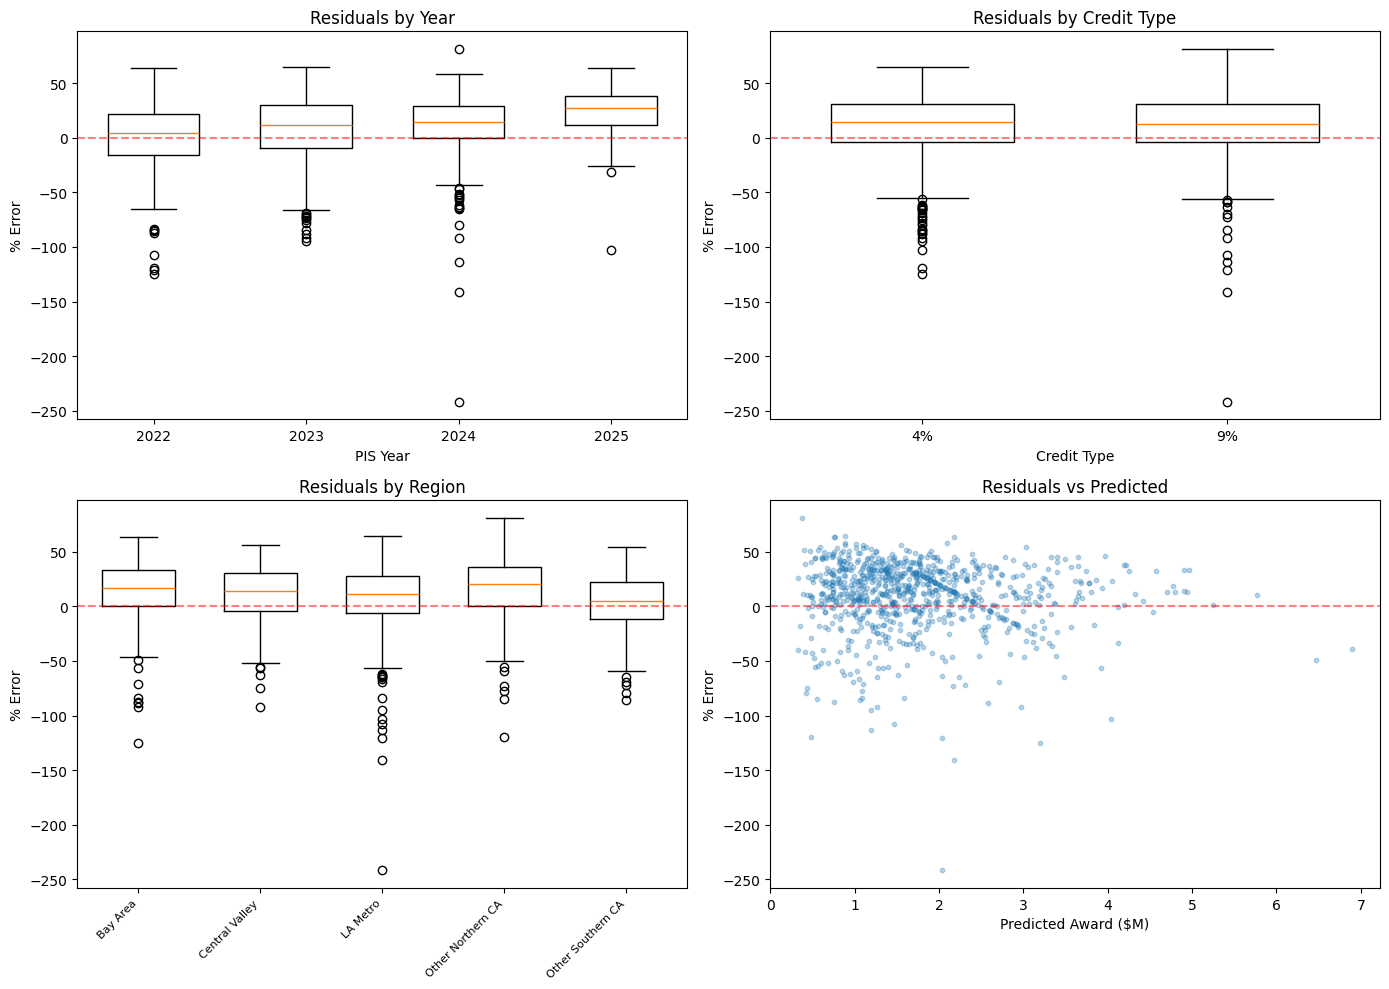

Median % error by credit type:
  4%: 14.7%
  9%: 12.8%

Median % error by region:
  Bay Area: 17.0%
  Central Valley: 13.6%
  LA Metro: 11.6%
  Other Northern CA: 20.6%
  Other Southern CA: 5.2%


In [13]:
# Use XGBoost as the best model for residual analysis
residuals = y_test_raw - xgb_preds
pct_errors = residuals / y_test_raw * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals by year
ax = axes[0, 0]
for year in sorted(df_test['pis_year'].unique()):
    mask = df_test['pis_year'].values == year
    ax.boxplot(pct_errors[mask], positions=[year], widths=0.6)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('PIS Year')
ax.set_ylabel('% Error')
ax.set_title('Residuals by Year')

# 2. Residuals by credit type
ax = axes[0, 1]
for i, ct in enumerate(sorted(df_test['credit_type'].unique())):
    mask = df_test['credit_type'].values == ct
    ax.boxplot(pct_errors[mask], positions=[i], widths=0.6, labels=[ct])
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Credit Type')
ax.set_ylabel('% Error')
ax.set_title('Residuals by Credit Type')

# 3. Residuals by region
ax = axes[1, 0]
regions = sorted(df_test['region'].unique())
for i, reg in enumerate(regions):
    mask = df_test['region'].values == reg
    ax.boxplot(pct_errors[mask], positions=[i], widths=0.6)
ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('% Error')
ax.set_title('Residuals by Region')

# 4. Residuals vs predicted (heteroscedasticity check)
ax = axes[1, 1]
ax.scatter(xgb_preds / 1e6, pct_errors, alpha=0.3, s=10)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Predicted Award ($M)')
ax.set_ylabel('% Error')
ax.set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

# Summary stats by subgroup
print('Median % error by credit type:')
for ct in sorted(df_test['credit_type'].unique()):
    mask = df_test['credit_type'].values == ct
    print(f'  {ct}: {np.median(pct_errors[mask]):.1f}%')

print('\nMedian % error by region:')
for reg in regions:
    mask = df_test['region'].values == reg
    print(f'  {reg}: {np.median(pct_errors[mask]):.1f}%')

## 13. SHAP Explainability

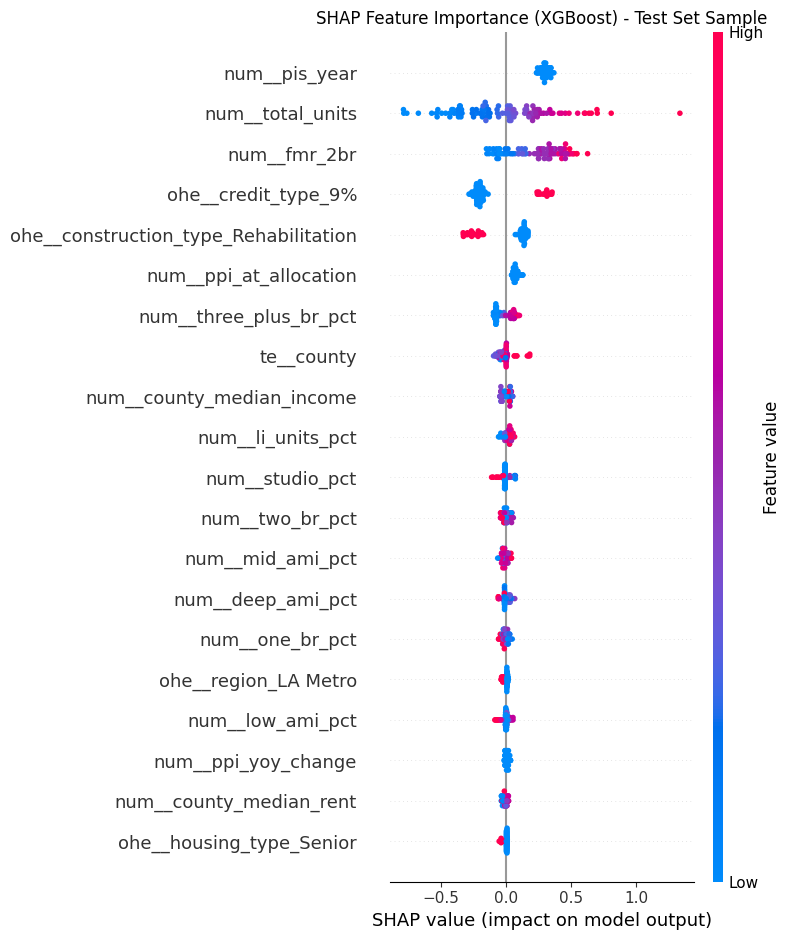

In [14]:


# SHAP for XGBoost (TreeExplainer)
# Use a sample of 100 test rows to keep memory usage reasonable
xgb_explainer = shap.TreeExplainer(xgb)
shap_sample = X_test[:100]
shap_values = xgb_explainer.shap_values(shap_sample)

# Global feature importance
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, shap_sample, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance (XGBoost) - Test Set Sample')
plt.tight_layout()
plt.show()

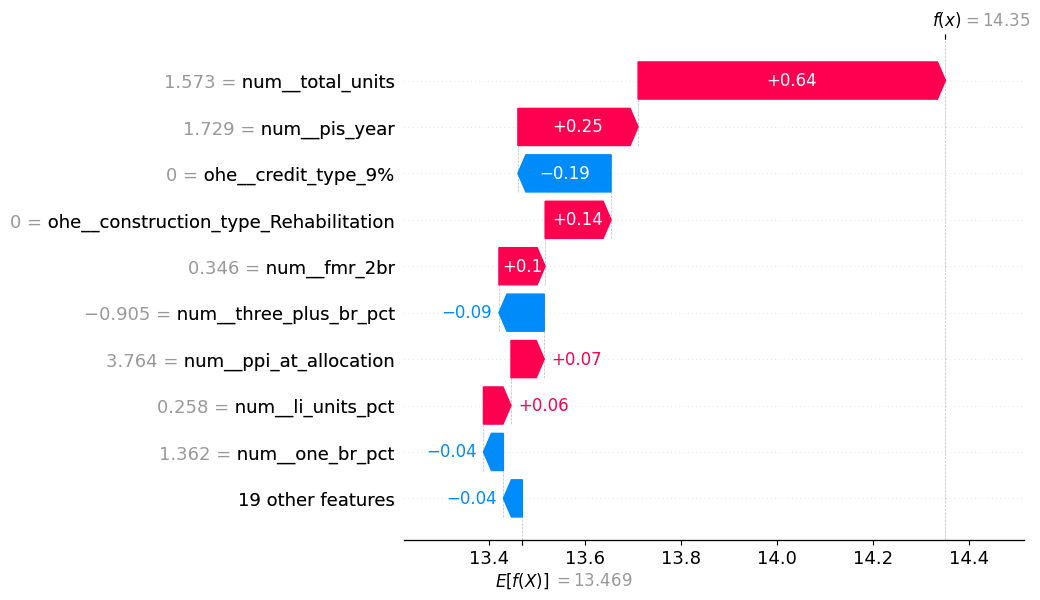

In [15]:
# Per-prediction waterfall for the first test observation
shap.initjs()
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=xgb_explainer.expected_value,
    data=X_test[0],
    feature_names=feature_names,
)
shap.waterfall_plot(explanation)

## 14. Actual vs Predicted Plot

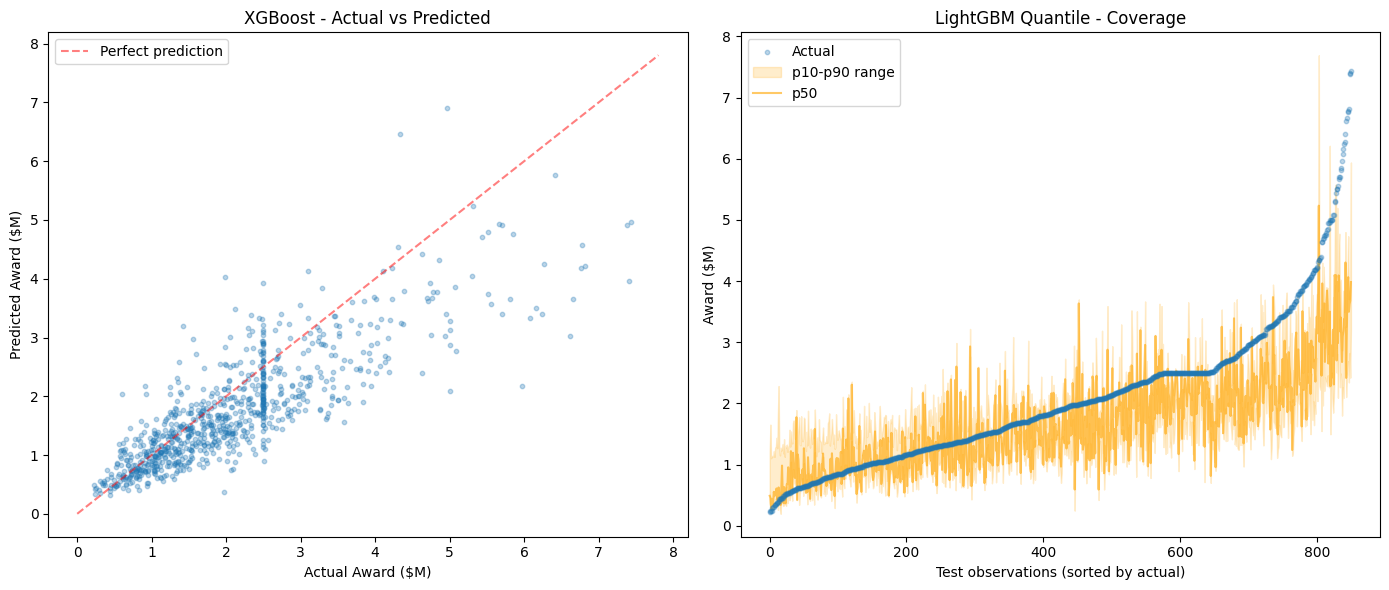

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost: actual vs predicted
ax = axes[0]
ax.scatter(y_test_raw / 1e6, xgb_preds / 1e6, alpha=0.3, s=10)
lims = [0, max(y_test_raw.max(), xgb_preds.max()) / 1e6 * 1.05]
ax.plot(lims, lims, 'r--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual Award ($M)')
ax.set_ylabel('Predicted Award ($M)')
ax.set_title('XGBoost - Actual vs Predicted')
ax.legend()

# LightGBM quantile: actual vs p50 with confidence bands
ax = axes[1]
sort_idx = np.argsort(y_test_raw)
ax.scatter(range(len(y_test_raw)), y_test_raw[sort_idx] / 1e6, alpha=0.3, s=10, label='Actual', zorder=3)
ax.fill_between(range(len(y_test_raw)), 
                p10_preds[sort_idx] / 1e6, p90_preds[sort_idx] / 1e6,
                alpha=0.2, color='orange', label='p10-p90 range')
ax.plot(range(len(y_test_raw)), p50_preds[sort_idx] / 1e6, 'orange', alpha=0.6, label='p50')
ax.set_xlabel('Test observations (sorted by actual)')
ax.set_ylabel('Award ($M)')
ax.set_title('LightGBM Quantile - Coverage')
ax.legend()

plt.tight_layout()
plt.show()

## 15. Market Comparables — KNN

In [17]:
# KNN on the full scoped dataset (train + test) for market comparables
X_all = np.vstack([X_train, X_test])
df_all = pd.concat([df_train, df_test], ignore_index=True)

knn = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
knn.fit(X_all)

# Demo: find 10 nearest neighbors for the first test project
distances, indices = knn.kneighbors(X_test[:1])

print(f'Query project: {df_test.iloc[0]["project_name"]} ({df_test.iloc[0]["county"]}, {df_test.iloc[0]["pis_year"]})')
print(f'Annual Federal Award: ${df_test.iloc[0]["annual_federal_award"]:,.0f}')
print(f'\nTop 10 comparable projects:')
comps = df_all.iloc[indices[0]][['project_name', 'county', 'pis_year', 'credit_type', 
                                  'housing_type', 'total_units', 'annual_federal_award']].copy()
comps['distance'] = distances[0]
comps

Query project: Northlake Senior Apartments (Sacramento, 2022)
Annual Federal Award: $1,487,569

Top 10 comparable projects:


,project_name,county,pis_year,credit_type,housing_type,total_units,annual_federal_award,distance
3536,Northlake Senior Apartments,Sacramento,2022,4%,Senior,191.0000,"1,487,569.0000",0.0000
3595,Steinbeck Commons,Monterey,2022,4%,Senior,100.0000,"1,274,287.0000",0.0000
3643,Sunny Garden Apartments,Los Angeles,2022,4%,Senior,95.0000,"998,652.0000",0.0000
3709,Harris Family Senior Residence,San Diego,2022,4%,Senior,117.0000,"1,280,396.0000",0.0000
3687,Cadence (FKA: 11408 S Central Avenue),Los Angeles,2022,4%,Non-Targeted,64.0000,"1,527,623.0000",0.0000
3639,Foothill Villas,San Bernardino,2022,4%,Large Family,239.0000,"3,022,196.0000",0.0000
3558,Adams Terrace,Los Angeles,2022,4%,Senior,86.0000,"2,236,487.0000",0.0000
3652,Central City I (Site 1),Sacramento,2022,4%,Non-Targeted,192.0000,"2,364,967.0000",0.0000
3680,Castle Argyle,Los Angeles,2022,4%,Senior,96.0000,"2,303,401.0000",0.0000
3628,Plymouth Place,San Joaquin,2022,4%,At-Risk,65.0000,"941,630.0000",0.0000


## 16. Project Archetypes — KMeans

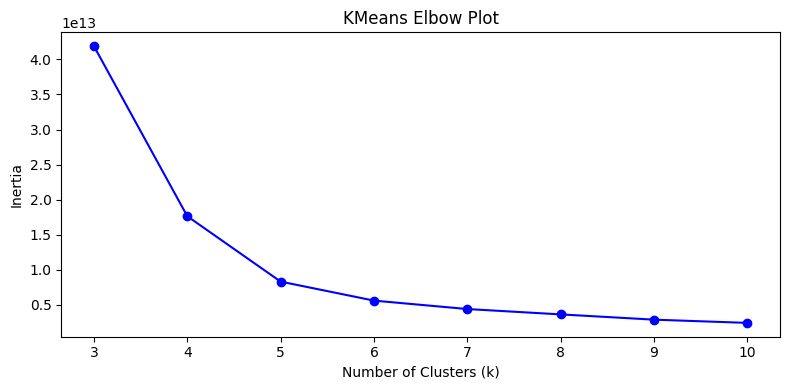

In [18]:
# Determine optimal k via inertia elbow
inertias = []
K_range = range(3, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_all)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'bo-')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('KMeans Elbow Plot')
plt.tight_layout()
plt.show()

In [19]:
# Fit final KMeans with k=6 (adjust based on elbow plot)
N_CLUSTERS = 6
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_all['cluster'] = kmeans.fit_predict(X_all)

# Cluster profiles
cluster_profile = df_all.groupby('cluster').agg(
    count=('annual_federal_award', 'size'),
    median_award=('annual_federal_award', 'median'),
    median_units=('total_units', 'median'),
    top_credit_type=('credit_type', lambda x: x.mode().iloc[0]),
    top_housing_type=('housing_type', lambda x: x.mode().iloc[0]),
    top_region=('region', lambda x: x.mode().iloc[0]),
    median_year=('pis_year', 'median'),
).reset_index()

print('Cluster Profiles (Project Archetypes):')
cluster_profile

Cluster Profiles (Project Archetypes):


,cluster,count,median_award,median_units,top_credit_type,top_housing_type,top_region,median_year
0,0,948,"728,152.5000",74.0000,4%,Large Family,Other Northern CA,"2,014.0000"
1,1,205,"1,654,658.0000",100.0000,4%,Non-Targeted,Bay Area,"2,016.0000"
2,2,1043,"1,058,195.0000",81.0000,4%,Large Family,Bay Area,"2,015.0000"
3,3,1438,"908,052.0000",65.0000,4%,Large Family,LA Metro,"2,014.0000"
4,4,178,"691,302.0000",56.5000,9%,Large Family,Other Northern CA,"2,016.0000"
5,5,575,"677,339.0000",63.0000,9%,Large Family,Central Valley,"2,013.0000"


## 17. Save All Models

In [ ]:
# Save individual base models
joblib.dump(ridge, os.path.join(MODEL_DIR, 'ridge_model.pkl'))
joblib.dump(rf, os.path.join(MODEL_DIR, 'rf_model.pkl'))
joblib.dump(xgb, os.path.join(MODEL_DIR, 'xgb_model.pkl'))
print('Saved: models/ridge_model.pkl, rf_model.pkl, xgb_model.pkl (XGBoost is the deployed point estimator)')

# Save quantile models (tuned per quantile, Section 8a) — offline benchmark
joblib.dump(quantile_models, os.path.join(MODEL_DIR, 'credit_quantile.pkl'))
print('Saved: models/credit_quantile.pkl (LightGBM p10/p50/p90, tuned)')

# Save split-conformal calibration (Section 8b) — deployed by the app for the 90% interval
joblib.dump(
    {'q_hat': q_hat, 'alpha': alpha_conf, 'n_cal': n_cal,
     'coverage_test': conf_coverage, 'mean_width': conf_width},
    os.path.join(MODEL_DIR, 'conformal_calibration.pkl'),
)
print('Saved: models/conformal_calibration.pkl (split-conformal on XGBoost)')

# Save KNN and KMeans
joblib.dump(knn, os.path.join(MODEL_DIR, 'knn_model.pkl'))
joblib.dump(kmeans, os.path.join(MODEL_DIR, 'kmeans_model.pkl'))
print('Saved: models/knn_model.pkl, kmeans_model.pkl')

# Save the SHAP explainer
joblib.dump(xgb_explainer, os.path.join(MODEL_DIR, 'shap_explainer.pkl'))
print('Saved: models/shap_explainer.pkl')

# Save the full scoped dataset (for comparables lookup in the app)
df_all.to_parquet(os.path.join(MODEL_DIR, 'df_all_scoped.parquet'), index=False)
print('Saved: models/df_all_scoped.parquet')

# Save model comparison results
results_df.to_csv(os.path.join(MODEL_DIR, 'model_comparison.csv'), index=False)
print('Saved: models/model_comparison.csv')

## 18. Summary

In [21]:
print('=' * 60)
print('NOTEBOOK 04 - MODELING SUMMARY')
print('=' * 60)
print(f'Training set:  {X_train.shape[0]:,} rows (2000-2021)')
print(f'Test set:      {X_test.shape[0]:,} rows (2022-2025)')
print(f'Features:      {X_train.shape[1]} (after encoding)')
print(f'Target:        log1p(annual_federal_award)')
print()
print('Models trained and saved:')
print('  1. Ridge Regression (baseline)')
print('  2. Random Forest (tuned via RandomizedSearchCV + TimeSeriesCV)')
print('  3. XGBoost (tuned via RandomizedSearchCV + TimeSeriesCV) <- best point estimator')
print('  4. Stacking v2: RF + XGBoost + LightGBM-p50 -> Ridge meta')
print('  5a. LightGBM Quantile p10/p50/p90 (tuned per-quantile, pinball loss)')
print('  5b. Split conformal on XGBoost (distribution-free intervals)')
print('  6. KNN (k=10, cosine) <- market comparables')
print(f'  7. KMeans (k={N_CLUSTERS}) <- project archetypes')
print()
print(f'LGBM p10-p90 coverage:       {lgbm_coverage:.1f}%  (width ${lgbm_width:,.0f})')
print(f'Conformal 90% coverage:      {conf_coverage:.1f}%  (width ${conf_width:,.0f})')
print()
print('Saved artifacts in models/:')
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'  {f} ({size:.0f} KB)')
print('=' * 60)
print('\nNext: Build streamlit_app.py')

NOTEBOOK 04 - MODELING SUMMARY
Training set:  3,536 rows (2000-2021)
Test set:      851 rows (2022-2025)
Features:      28 (after encoding)
Target:        log1p(annual_federal_award)

Models trained and saved:
  1. Ridge Regression (baseline)
  2. Random Forest (tuned via RandomizedSearchCV + TimeSeriesCV)
  3. XGBoost (tuned via RandomizedSearchCV + TimeSeriesCV) <- best point estimator
  4. Stacking v2: RF + XGBoost + LightGBM-p50 -> Ridge meta
  5a. LightGBM Quantile p10/p50/p90 (tuned per-quantile, pinball loss)
  5b. Split conformal on XGBoost (distribution-free intervals)
  6. KNN (k=10, cosine) <- market comparables
  7. KMeans (k=6) <- project archetypes

LGBM p10-p90 coverage:       49.0%  (width $844,597)
Conformal 90% coverage:      84.5%  (width $1,902,730)

Saved artifacts in models/:
  X_test.npy (186 KB)
  X_test_v1.npy (186 KB)
  X_train.npy (774 KB)
  X_train_v1.npy (774 KB)
  conformal_calibration.pkl (0 KB)
  credit_model.pkl (230 KB)
  credit_quantile.pkl (1466 KB)
